In [1]:
import numpy as np
import json
from tqdm import tqdm

In [2]:
from src.display import visualize_moment
from src.gather import get_event_logs, get_logs, possession_team
from src.process import ProcessedMoment
from src.event import Event, Game, Season

In [3]:
with open("games/0021500438.json") as f:
    game = json.load(f)

In [4]:
print(game.keys())
print(len(game['events']))
print(game['events'][0].keys())
print(len(game['events'][0]['moments']))
print(len(game['events'][0]['moments'][0]))

print("-------------")
for val in game['events'][0]['moments'][0]:
    print(val)

dict_keys(['gameid', 'gamedate', 'events'])
493
dict_keys(['eventId', 'visitor', 'home', 'moments'])
149
6
-------------
1
1451082035065
720.0
24.0
None
[[-1, -1, 46.25174, 27.56612, 3.4819], [1610612744, 101106, 50.28268, 26.11096, 0.0], [1610612744, 201575, 50.28268, 26.11096, 0.0], [1610612744, 201939, 77.69071, 24.66218, 0.0], [1610612744, 202691, 49.74069, 32.55629, 0.0], [1610612744, 203110, 58.22998, 24.8341, 0.0], [1610612739, 2544, 43.90252, 15.81125, 0.0], [1610612739, 2747, 45.66055, 32.43427, 0.0], [1610612739, 201567, 36.68877, 24.80455, 0.0], [1610612739, 202681, 45.66055, 32.43427, 0.0], [1610612739, 202389, 44.76942, 25.42155, 0.0]]


In [5]:
Event(game['events'][11])

In [6]:
gm = Game(game)

In [7]:
# ev_logs, ev_idx, nerr = get_event_logs(game['events'][128], bound_start=599.09)

# print(len(ev_logs), nerr)

# possession_team(ev_logs)

In [8]:
gm.errors

[]

In [9]:
len(gm.errors), len(gm.events)

(0, 186)

In [10]:
rng = np.random.default_rng(seed=123)

grav = {}

for pl in gm.home['players'] + gm.away['players']:
    pl_id = pl['playerid']
    grav[pl_id] = np.exp(rng.normal())
for i in [-1,-2]:
    grav[i] = np.exp(rng.normal())

grav

{101106: np.float64(0.37190332022766404),
 203105: np.float64(0.692264859626372),
 203949: np.float64(3.6252572861920394),
 202691: np.float64(1.2140652257174613),
 203110: np.float64(2.5098698510797406),
 201574: np.float64(1.7808731740733474),
 201575: np.float64(0.5291604175163883),
 201578: np.float64(1.719360157926617),
 201939: np.float64(0.7286254600908438),
 203546: np.float64(0.7244162534103393),
 2733: np.float64(1.1020447508582012),
 2738: np.float64(0.21741867497857714),
 2571: np.float64(3.2942090845438883),
 201567: np.float64(0.5111512853419641),
 202389: np.float64(2.719014285688344),
 202684: np.float64(1.1460498584569652),
 202681: np.float64(4.627575494406395),
 202697: np.float64(0.5168671432559776),
 203099: np.float64(0.7321317049063288),
 2747: np.float64(1.4018168237682436),
 2760: np.float64(0.1099784217656231),
 203521: np.float64(2.2885568938405654),
 2544: np.float64(4.6722015972467865),
 2210: np.float64(3.0857871946917292),
 2590: np.float64(2.127121472384

In [11]:
gm.loss(grav, 0.2, 2)

np.float64(5541648.342245426)

In [12]:
gm.events[0].loss(grav, 0.2, 2)

np.float64(7190.898938063975)

In [13]:
gm.events[0].moments[0].loss(grav, 0.2, 2)

np.float64(419.43185353778756)

In [14]:
gm.events[0].moments[0].resid(grav, 0.2, 2)

{101106: array([ 5.47629787, -7.26133865]),
 201575: array([0.2830633 , 1.87490727]),
 201939: array([-0.41804606,  0.13946391]),
 202691: array([8.5809158 , 1.53379804]),
 203110: array([15.85300006, -2.37130726])}

In [15]:
gm.events[0].moments[0].def_loc

{101106: array([79.18133, 31.84306]),
 201575: array([64.70901, 26.64668]),
 201939: array([75.40104, 21.66398]),
 202691: array([66.71983, 11.21139]),
 203110: array([79.11448, 31.79202])}

In [16]:
gm.events[0].moments[0].predicted_locations(grav)

{101106: array([73.70503213, 39.10439865]),
 201575: array([64.4259467 , 24.77177273]),
 201939: array([75.81908606, 21.52451609]),
 202691: array([58.1389142 ,  9.67759196]),
 203110: array([63.26147994, 34.16332726])}

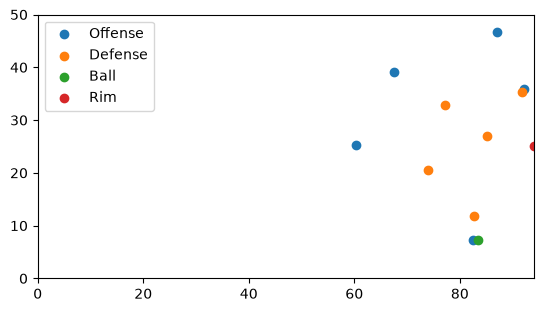

In [17]:
EVENT_IDX = 0
MOMENT_IDX = 30

visualize_moment(gm.events[EVENT_IDX].logs[MOMENT_IDX], gm.events[EVENT_IDX].poss_team)

In [18]:
gm.events[EVENT_IDX].moments[MOMENT_IDX].assignments()

[4, 0, 1, 3, 2]

In [19]:
gm.events[EVENT_IDX].moments[MOMENT_IDX].poss_team_id

1610612739

In [20]:
gm.events[EVENT_IDX].logs[MOMENT_IDX].location_list()

[[-1, -1, array([83.45005,  7.26193])],
 [1610612744, 101106, array([85.17909, 26.92054])],
 [1610612744, 201575, array([82.70822, 11.87114])],
 [1610612744, 201939, array([73.93154, 20.50619])],
 [1610612744, 202691, array([91.8333 , 35.33461])],
 [1610612744, 203110, array([77.10075, 32.91142])],
 [1610612739, 2544, array([82.56018,  7.33288])],
 [1610612739, 2747, array([60.33217, 25.27593])],
 [1610612739, 201567, array([67.58892, 39.05621])],
 [1610612739, 202681, array([87.12249, 46.61179])],
 [1610612739, 202389, array([92.10483, 35.93942])]]

# Temp

TO DO:
- Figure out why season.loss gives different value than loss returned by solver.solve_mass()
- Check to see if solve.fit_alternating() works
- see if anything useful from advanced folder
- ask Chat how to better structure repo
- Modification: adjust gravity towards zero for players with little playing time (maybe alpha penalty increases for players with low number possessions)
- Brainstorm extensions: 
    - gravity dependent on whether player has ball or is off ball; gravity depend on both player AND position on court (in nontrivial way; positional effects different for different players)
    - Analogy to gravity: try to think of way to model how offensive player gravities + offensive player positions/movement affects way defenders move (analgous to curvature of spacetime affecting how objects move across because of geodesics)
    - Make more mathematically nice: get rid of discontinuity from way matchups are done
    - Try to reconcile with real defensive principles: different if defender behind play, account for help position
    - Include momentum towards rim as something that affects gravity in that instant (could account for help defense?)
    - Create a defensive mass: how stationary is defender vs how much reacts to the changes in curvature [wait, actually does mass of the second object even impact change in motion because under Newton's law would increase the force but also increase inertia so should cancel out; unsure about this]
    - Extremely advanced extension: try to incorporate Einstein's general relativity equations instead of using Newton's law [this is almost 100% not worth it]
    - Ultimate goal: want some model saying how defense reacts based on offensive action (given by tracking data and players on floor; know what defense does and know offensive actions so only unknown is how players on floor affect things) 
- Gravity Analogy
    - Curvature of spacetime = curvature of court
    - Mass / energy = offensive player mass and position and momentum
    - Defenders move approximately according to "geodesics" of court curvature created by offensive players


In [1]:
import numpy as np
import json

In [2]:
from src.event import Season
from src.solver import Solver

In [4]:
with open("games/0021500438.json") as f:
    game = json.load(f)

In [5]:
season = Season([game])

In [6]:
m, lst, ls = season.solve_mass(rim_weight=0.2, p=2, alpha=1.)
m

array([ 3.23189569,  6.74847047, 10.60924703,  5.36761376,  6.31377501,
        3.34460992,  7.01640016,  2.82712936,  4.11320166, -0.76242908,
        2.49560321,  2.57692459,  6.47555613, 11.31818496,  0.59396956,
        9.48472107,  4.31639756,  8.98291138,  3.63933665,  4.23468434,
        6.34861851, 11.92868509, 12.72109029,  3.22566098])

In [7]:
grav2 = {a : b for (a,b) in zip(lst, m)}

season.loss(grav2, rim_weight=0.2, p=2, alpha=1., with_alpha=True)

np.float64(5430922.877103325)

In [8]:
ls

np.float64(5438458.99833367)

In [ ]:
# season.loss(grav, rim_weight=0.2, p=2)

np.float64(5541648.342245426)

In [33]:
name_to_grav = {}

for player in season.games[0].away['players'] + season.games[0].home['players']:
    if player['playerid'] not in grav2:
        continue
    name = f"{player['firstname']} {player['lastname']}"
    name_to_grav[name] = np.round(grav2[player['playerid']],2)
    # print(f"{player['firstname']} {player['lastname']}: {np.round(grav2[player['playerid']],2)}")

for name, grav in sorted(name_to_grav.items(), key = lambda x : x[1], reverse=True):
    print(f"{name}: {grav}")

Ian Clark: 12.72
Matthew Dellavedova: 11.93
Stephen Curry: 11.32
LeBron James: 10.61
Kyrie Irving: 9.48
Klay Thompson: 8.98
Shaun Livingston: 7.02
Marreese Speights: 6.48
Draymond Green: 6.35
Mo Williams: 6.31
Leandro Barbosa: 5.37
Tristan Thompson: 4.32
Festus Ezeli: 4.23
J.R. Smith: 4.11
Iman Shumpert: 3.64
James Jones: 3.34
James Michael McAdoo: 3.23
Andre Iguodala: 2.83
Brandon Rush: 2.58
Kevin Love: 2.5
Timofey Mozgov: 0.59
Andrew Bogut: -0.76


# Minimization starter code

A few things to do:
- use scipy optimize to find best exponential power (p) and rim weight
- Iterate between solving for off player masses and rim weight / p params

In [ ]:
def objective(theta):

    gravity = {
        pid: np.exp(val)
        for pid, val in zip(player_ids, theta)
    }

    loss = sum(moment.loss(gravity) for moment in moments)

    reg = 0.01*np.sum(theta**2)

    return loss + reg

In [ ]:
from scipy.optimize import minimize

def objective(x):

    gravity = dict(zip(player_ids, x))

    return sum(moment.loss(gravity) for moment in moments)

x0 = np.ones(len(player_ids))

result = minimize(objective, x0)

gravity_hat = dict(zip(player_ids, result.x))